## preparing TA snRNA dataset using Scanpy

In [2]:
import scanpy as sc
import anndata as ad
from scipy import io
from scipy.sparse import coo_matrix, csr_matrix
import scipy.sparse as sp
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os
import json
import glob
import sys

#### Load objects to construct adata

In [3]:
output_dir = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/adata_export'

# Load X matrix
if os.path.exists(f'{output_dir}/X_matrix.npz'):
    X = sp.load_npz(f'{output_dir}/X_matrix.npz')
    print("Loaded sparse X matrix")
else:
    X = np.load(f'{output_dir}/X_matrix.npy')
    print("Loaded dense X matrix")

# Load obs and var
obs = pd.read_csv(f'{output_dir}/obs.csv', index_col=0)
var = pd.read_csv(f'{output_dir}/var.csv', index_col=0)
print(f"Loaded obs: {obs.shape}, var: {var.shape}")

# Loading layers back
layers = {}
for key in ['cellbender', 'counts', 'scvi_normalized']:
    npz_path = f'{output_dir}/layers_{key}.npz'
    npy_path = f'{output_dir}/layers_{key}.npy'
    if os.path.exists(npz_path):
        layers[key] = sp.load_npz(npz_path)
    elif os.path.exists(npy_path):
        layers[key] = np.load(npy_path)

# Create AnnData object
adata = ad.AnnData(X=X, obs=obs, var=var, layers=layers)
print(f"Created AnnData: {adata.shape}")

# Load obsm
for file in glob.glob(f'{output_dir}/obsm_*.csv'):
    key = file.split('obsm_')[1].replace('.csv', '')
    df = pd.read_csv(file, index_col=0)
    adata.obsm[key] = df.values
    print(f"Loaded obsm['{key}']: {df.shape}")

# 5. Load varm
for file in glob.glob(f'{output_dir}/varm_*.csv'):
    key = file.split('varm_')[1].replace('.csv', '')
    df = pd.read_csv(file, index_col=0)
    adata.varm[key] = df.values
    print(f"Loaded varm['{key}']: {df.shape}")

# 6. Load obsp
for file in glob.glob(f'{output_dir}/obsp_*.npz'):
    key = file.split('obsp_')[1].replace('.npz', '')
    adata.obsp[key] = sp.load_npz(file)
    print(f"Loaded obsp['{key}']")

# 7. Load varp
for file in glob.glob(f'{output_dir}/varp_*.npz'):
    key = file.split('varp_')[1].replace('.npz', '')
    adata.varp[key] = sp.load_npz(file)
    print(f"Loaded varp['{key}']")

# 8. Load uns
adata.uns = {}
if os.path.exists(f'{output_dir}/uns.json'):
    with open(f'{output_dir}/uns.json', 'r') as f:
        adata.uns.update(json.load(f))
    print(f"Loaded {len(adata.uns)} entries from uns.json")

# Load numpy arrays in uns
for file in glob.glob(f'{output_dir}/uns_*.npy'):
    key = os.path.basename(file).split('uns_')[1].replace('.npy', '')
    adata.uns[key] = np.load(file, allow_pickle=True)
    print(f"Loaded uns['{key}']")

# Load DataFrames in uns
for file in glob.glob(f'{output_dir}/uns_*.csv'):
    key = os.path.basename(file).split('uns_')[1].replace('.csv', '')
    adata.uns[key] = pd.read_csv(file, index_col=0)
    print(f"Loaded uns['{key}']")

# Load raw if exists
if os.path.exists(f'{output_dir}/raw_X.npz'):
    raw_X = sp.load_npz(f'{output_dir}/raw_X.npz')
    print("Loaded raw sparse matrix")
elif os.path.exists(f'{output_dir}/raw_X.npy'):
    raw_X = np.load(f'{output_dir}/raw_X.npy')
    print("Loaded raw dense matrix")
else:
    raw_X = None

if raw_X is not None:
    raw_var = pd.read_csv(f'{output_dir}/raw_var.csv', index_col=0)
    adata.raw = ad.AnnData(X=raw_X, var=raw_var, obs=adata.obs)
    print(f"Loaded raw data: {adata.raw.X.shape}")

# Clean uns to remove problematic entries
print("\nChecking uns entries:")
uns_cleaned = {}
for key, val in adata.uns.items():
    try:
        # Try to create a temporary h5ad file to test if this entry can be saved
        test_adata = ad.AnnData(X=adata.X[:10, :10], obs=adata.obs.iloc[:10], var=adata.var.iloc[:10])
        test_adata.uns[key] = val
        test_adata.write('/tmp/test_uns.h5ad')
        uns_cleaned[key] = val
        print(f"  ✓ uns['{key}'] - OK")
    except Exception as e:
        print(f"  ✗ uns['{key}'] - Error: {type(e).__name__}")
        # Try to convert to something saveable
        if isinstance(val, dict):
            print(f"    Attempting to clean dict...")
            try:
                # For dict entries, try to save just the serializable parts
                clean_dict = {}
                for k, v in val.items():
                    if isinstance(v, (str, int, float, bool, np.ndarray, list)):
                        clean_dict[k] = v
                uns_cleaned[key] = clean_dict
                print(f"    Cleaned dict saved")
            except:
                print(f"    Skipping {key}")
        else:
            print(f"    Skipping {key}")

# Replace uns with cleaned version
adata.uns = uns_cleaned
print(f"\nCleaned uns: {len(uns_cleaned)} entries retained")

Loaded sparse X matrix
Loaded obs: (86672, 36), var: (3000, 11)


/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Created AnnData: (86672, 3000)
Loaded obsm['X_pca']: (86672, 50)
Loaded obsm['X_scVI']: (86672, 32)
Loaded obsm['gene_expression_encoding']: (86672, 64)
Loaded obsm['X_pca_harmony']: (86672, 50)
Loaded obsm['X_scANVI']: (86672, 32)
Loaded obsm['X_umap']: (86672, 2)
Loaded varm['PCs']: (3000, 50)
Loaded obsp['distances']
Loaded obsp['connectivities']
Loaded 6 entries from uns.json
Loaded uns['cell_type_colors']
Loaded uns['C_scANVI_colors']
Loaded uns['batch_colors']
Loaded uns['sample_id_colors']
Loaded uns['pca']
Loaded uns['sex_colors']
Loaded uns['condition_colors']
Loaded raw sparse matrix
Loaded raw data: (86672, 20384)

Checking uns entries:


/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


  ✓ uns['_scvi_manager_uuid'] - OK
  ✓ uns['_scvi_uuid'] - OK
  ✓ uns['hvg'] - OK
  ✓ uns['log1p'] - OK
  ✓ uns['neighbors'] - OK
  ✓ uns['umap'] - OK
  ✓ uns['cell_type_colors'] - OK
  ✓ uns['C_scANVI_colors'] - OK
  ✓ uns['batch_colors'] - OK
  ✓ uns['sample_id_colors'] - OK
  ✗ uns['pca'] - Error: TypeError
    Skipping pca
  ✓ uns['sex_colors'] - OK
  ✓ uns['condition_colors'] - OK

Cleaned uns: 12 entries retained


In [ ]:
# Save with anndata 0.10.8
output_path = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/adata_harmony_celloracle_compatible_v2.h5ad'
adata.write(output_path)

print(f"\n✓ Reconstructed AnnData saved!")
print(f"  Shape: {adata.shape}")
print(f"  File: {output_path}")
print(f"  obsm keys: {list(adata.obsm.keys())}")
print(f"  uns keys: {list(adata.uns.keys())}")


✓ Reconstructed AnnData saved!
  Shape: (86672, 3000)
  File: /ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/adata_harmony_celloracle_compatible_v2.h5ad
  obsm keys: ['X_pca', 'X_scVI', 'gene_expression_encoding', 'X_pca_harmony', 'X_scANVI', 'X_umap']
  uns keys: ['_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'log1p', 'neighbors', 'umap', 'cell_type_colors', 'C_scANVI_colors', 'batch_colors', 'sample_id_colors', 'sex_colors', 'condition_colors']


In [6]:
# load anndata objects
adata = sc.read_h5ad('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/adata_harmony_celloracle_compatible_v2.h5ad')
adata

/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 86672 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'dispersions', 'dispersions_norm'
    uns: 'C_scANVI_colors', '_scvi_manager_uuid', '_scvi_uui

#### Filter more cells

In [7]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[:, (~adata.var['mt'] & ~adata.var['ribo'] & ~adata.var['hb'])] # Filter mitochondrial, ribosomal, haemoglobin genes
print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Number of cells after filtering of low quality cells: 81614


In [8]:
male_adata_subset = adata[adata.obs['sex'] == 'M']
female_adata_subset = adata[adata.obs['sex'] == 'F']

In [9]:
male_adata_subset

View of AnnData object with n_obs × n_vars = 40000 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'dispersions', 'dispersions_norm', 'n_cells'
    uns: 'C_scANVI_colors', '_scvi_manage

In [10]:
female_adata_subset

View of AnnData object with n_obs × n_vars = 41614 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'dispersions', 'dispersions_norm', 'n_cells'
    uns: 'C_scANVI_colors', '_scvi_manage

In [ ]:
# import numpy as np
# from scipy import sparse

# def convert_to_dense_full(adata):
#     """Convert all sparse matrices in AnnData to dense for Seurat compatibility"""
    
#     # Convert main matrix
#     if sparse.issparse(adata.X):
#         adata.X = adata.X.toarray()
    
#     # Convert layers
#     if adata.layers:
#         for layer_name in list(adata.layers.keys()):
#             if sparse.issparse(adata.layers[layer_name]):
#                 adata.layers[layer_name] = adata.layers[layer_name].toarray()
    
#     # Convert raw if it exists
#     if adata.raw is not None:
#         # Create a new AnnData for raw with dense matrix
#         raw_X = adata.raw.toarray() if sparse.issparse(adata.raw) else adata.raw
#         adata.raw = adata.raw.to_adata()
    
#     # Convert obsm (e.g., PCA, UMAP)
#     for key in list(adata.obsm.keys()):
#         if sparse.issparse(adata.obsm[key]):
#             adata.obsm[key] = adata.obsm[key].toarray()
    
#     # Convert varm
#     for key in list(adata.varm.keys()):
#         if sparse.issparse(adata.varm[key]):
#             adata.varm[key] = adata.varm[key].toarray()
    
#     # Convert obsp (pairwise obs matrices like connectivities)
#     for key in list(adata.obsp.keys()):
#         if sparse.issparse(adata.obsp[key]):
#             adata.obsp[key] = adata.obsp[key].toarray()
    
#     # Convert varp
#     for key in list(adata.varp.keys()):
#         if sparse.issparse(adata.varp[key]):
#             adata.varp[key] = adata.varp[key].toarray()
    
#     return adata

In [ ]:
# # Apply and save
# female_adata = convert_to_dense_full(female_adata_subset.copy())
# male_adata = convert_to_dense_full(male_adata_subset.copy())

# # Save
# female_adata.write_h5ad("/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/female_jan_26_dense.h5ad", compression='gzip')
# male_adata.write_h5ad("/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/male_jan_26_dense.h5ad", compression='gzip')

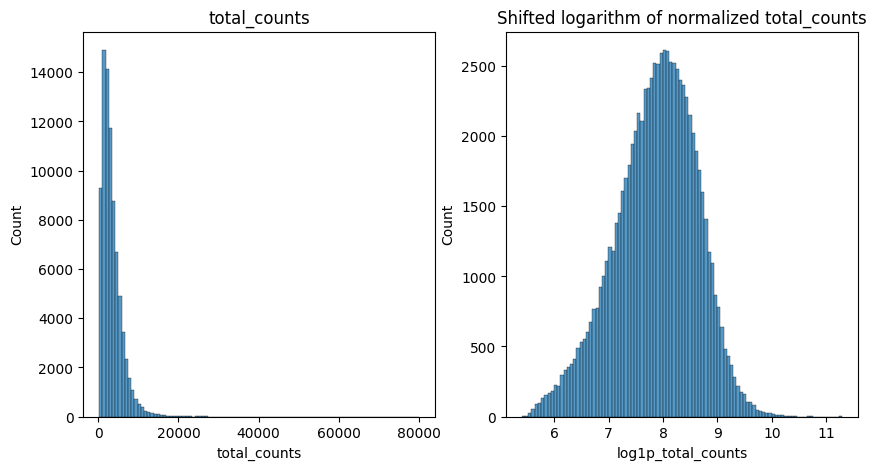

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("total_counts")
sns.histplot(adata.obs["log1p_total_counts"], bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm of normalized total_counts")
plt.show()

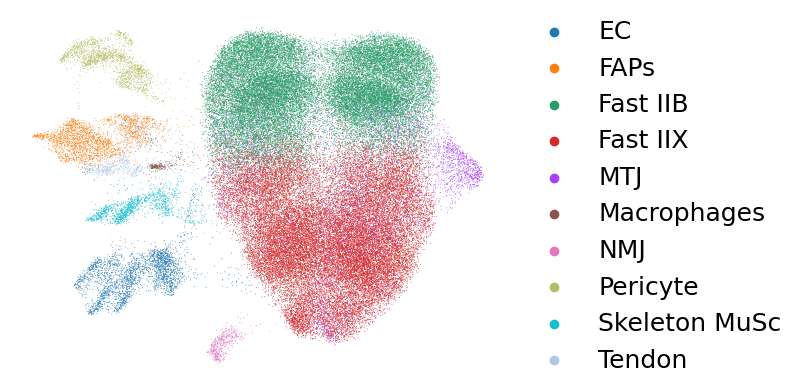

In [12]:
#umap colors by both cell metadata and var.names (gene_names)
sc.pl.umap(adata, color=['C_scANVI'], frameon=False, legend_fontsize=18,
           legend_fontweight='bold', legend_fontoutline=2, title='')

### Filter cells for stream input

In [13]:
## subset to only fast2b and fast2x cell types
male_adata_subset = male_adata_subset[male_adata_subset.obs['C_scANVI'].isin(['Fast IIB', 'Fast IIX'])]
female_adata_subset = female_adata_subset[female_adata_subset.obs['C_scANVI'].isin(['Fast IIB', 'Fast IIX'])]


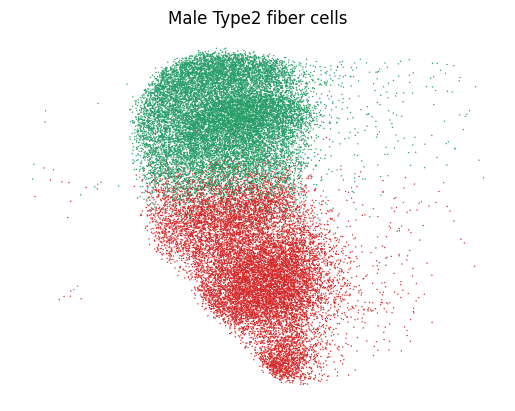

In [14]:
#umap colors by both cell metadata and var.names (gene_names)
sc.pl.umap(male_adata_subset, color=['C_scANVI'], frameon=False, title='Male Type2 fiber cells', show=True, legend_loc=None)

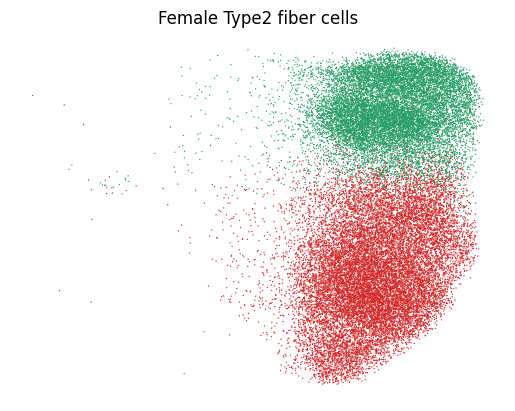

In [15]:
#umap colors by both cell metadata and var.names (gene_names)
sc.pl.umap(female_adata_subset, color=['C_scANVI'], frameon=False, title='Female Type2 fiber cells', show=True, legend_loc=None)

In [16]:
# save the filtered adata objects
male_adata_subset.write_h5ad("/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/male_adata_stream_input.h5ad")
female_adata_subset.write_h5ad("/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/female_adata_stream_input.h5ad")

### Checkout DEG rank for certain genes

In [9]:
########## file paths ##########
fast2b_path = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/analysis/male/degs/DEGs_KO_vs_WT_Fast_IIX.csv"
fast2x_path = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/analysis/male/degs/DEGs_KO_vs_WT_Fast_IIB.csv"
fast2b_degs = pd.read_csv(fast2b_path, header=0)
fast2x_degs = pd.read_csv(fast2x_path, header=0)

In [12]:
display(fast2b_degs.head())

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,cell_type
0,Myh4,16.312288,0.794730,8.071159e-60,1.076155e-56,0.479891,Fast IIX
1,Tpm1,15.371201,0.402362,2.553871e-53,2.043097e-50,0.835226,Fast IIX
2,Acta1,14.960452,1.430716,1.331191e-50,8.874605e-48,0.296664,Fast IIX
3,Samd4,14.436999,0.310271,3.027395e-47,1.345509e-44,0.892714,Fast IIX
4,Tnni2,14.374839,1.436111,7.444325e-47,2.977730e-44,0.259404,Fast IIX
